In [2]:
import os

# Ensure Kaggle directory exists
kaggle_dir = os.path.expanduser("~/.kaggle")
if not os.path.exists(kaggle_dir):
 os.makedirs(kaggle_dir)


In [3]:
# Confirm download
print("Files in directory:", os.listdir("./spotify_dataset"))

Files in directory: ['spotify_top_1000_tracks.csv']


In [32]:
import pandas as pd
import os

# Define the dataset path using your absolute file path
dataset_path = r"C:\Users\admin\OneDrive\Documents\ComProg_Lab\Lab7_DataVisualization\spotify_dataset\spotify_top_1000_tracks.csv"

# Load dataset
df = pd.read_csv(dataset_path, encoding="utf-8")

# Convert release_date and extract year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

#gemini y0 fix
df = df[df['year'] > 1900].copy()
df['decade'] = (df['year'] // 10) * 10

# FIX: We REMOVE the line that tried to create 'duration_min'
# because it already exists in the CSV file you loaded.
# (The 'duration_min' column is ready for use!)

print(" Dataset loaded and basic preprocessing complete!")
print(df.head(3))

 Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  decade  
0      3.869767  2018.0  2010.0  
1      3.840883  2016.0  2010.0  
2      3.1826

In [6]:
# DATA CLEANING

import numpy as np

# Clean up text columns
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()

# Convert 'year' to integer
df['year'] = df['year'].fillna(0).astype(int)

# Drop unnecessary columns
cols_to_drop = ['spotify_url', 'id', 'release_date']

# Check for and add other common audio feature columns if they exist
if 'time_signature' in df.columns:
 cols_to_drop.append('time_signature')
if 'key' in df.columns:
 cols_to_drop.append('key')
if 'mode' in df.columns:
 cols_to_drop.append('mode')

df = df.drop(columns=cols_to_drop, errors='ignore')

# Feature Engineering: Tempo Category
tempo_bins = [0, 100, 140, np.inf]
tempo_labels = ['Slow', 'Medium', 'Fast']

if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut( # Create tempo category column
        df['tempo'], bins=tempo_bins,
        labels=tempo_labels, right=False
    )
    print("Feature 'tempo_category' created.")
else:
    print("Warning: 'tempo' column not found; skipping 'tempo_category' creation.")

# Remove duplicates
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print(f" Data cleaning and feature engineering complete.")
print(f"Final Row Count after deduplication: {len(df)}")


 Data cleaning and feature engineering complete.
Final Row Count after deduplication: 971


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Edison"
student_id = "TUPM-25-4484" # Replace with your actual ID

id_num = int(student_id[-3:])
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5)
% 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4)
% 256:02x}"

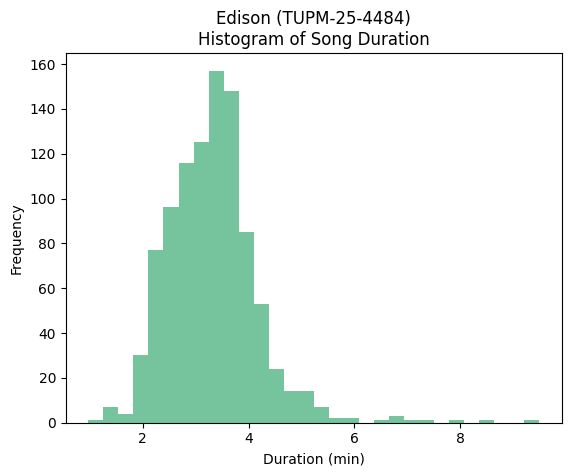

In [8]:
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()

In [21]:
print(df.columns)

Index(['track_name', 'artist', 'album', 'release_date', 'popularity',
       'spotify_url', 'id', 'duration_min', 'year'],
      dtype='str')


C:\Users\admin\AppData\Local\Temp\ipykernel_20148\2022922137.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


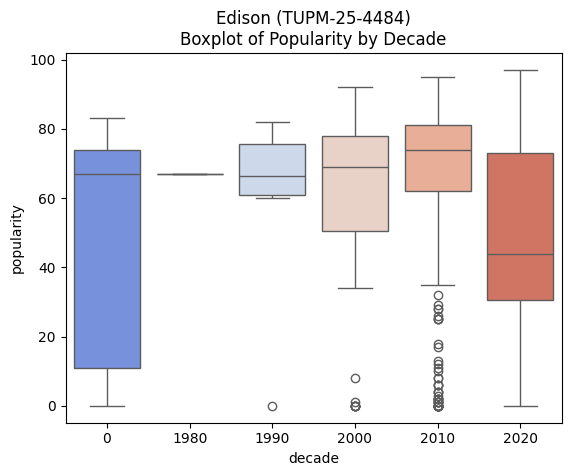

In [12]:
df['decade'] = (df['year'] // 10) * 10
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_20148\2607157399.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df,


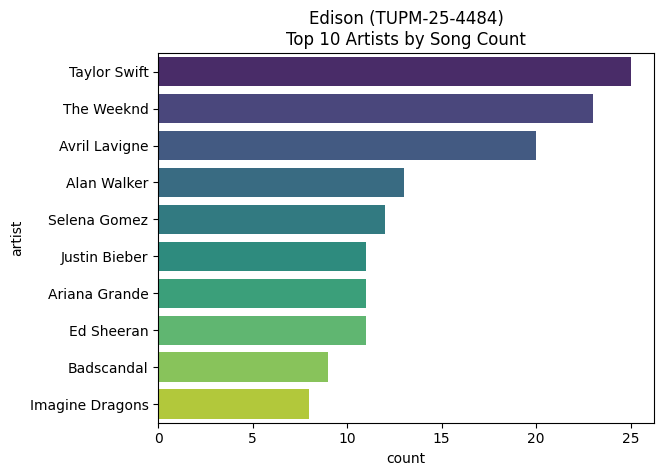

In [13]:
sns.countplot(y='artist', data=df,
order=df['artist'].value_counts().head(10).index, palette='viridis')
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.show()

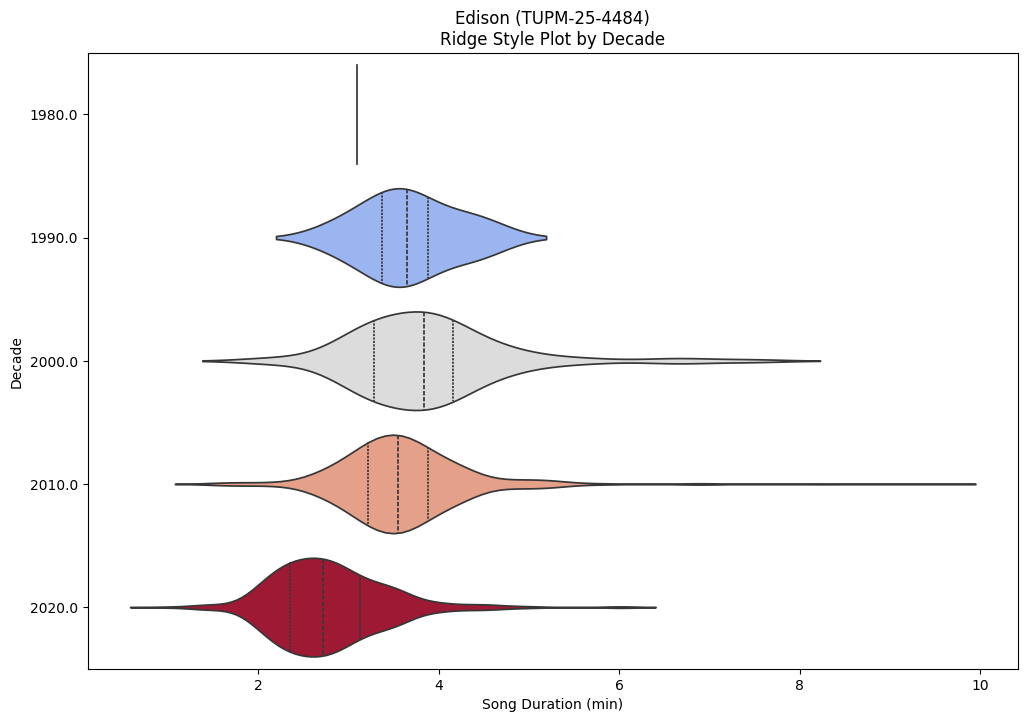

In [35]:
plt.figure(figsize=(12, 8))

sns.violinplot(
    data=df, 
    x='duration_min', 
    y='decade', 
    orient='h',            
    palette='coolwarm', 
    inner='quartile',      
    hue='decade',          
    legend=False
)


plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.xlabel("Song Duration (min)")
plt.ylabel("Decade")

plt.show()

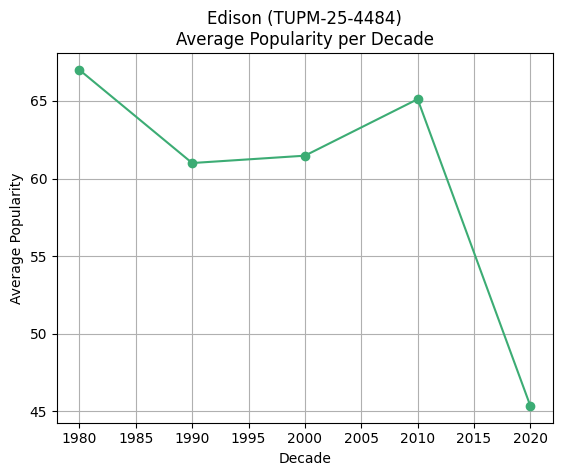

In [36]:
avg_pop = df.groupby('decade')['popularity'].mean()
avg_pop.plot(kind='line', color=color1, marker='o')
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True)
plt.show()

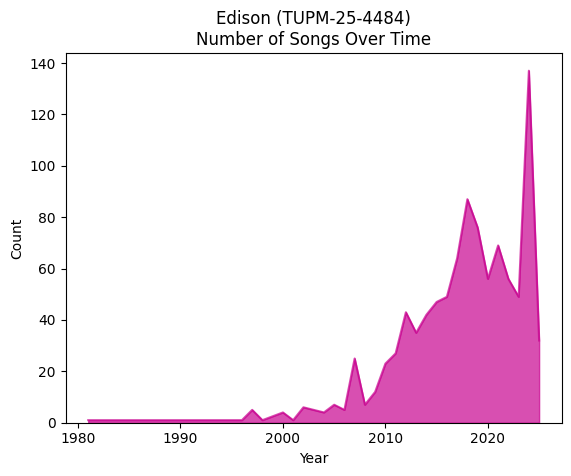

In [37]:
df['release_year'] = pd.to_datetime(df['release_date'],
errors='coerce').dt.year
count_by_year = df['release_year'].value_counts().sort_index()
count_by_year.plot(kind='area', color=color2, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


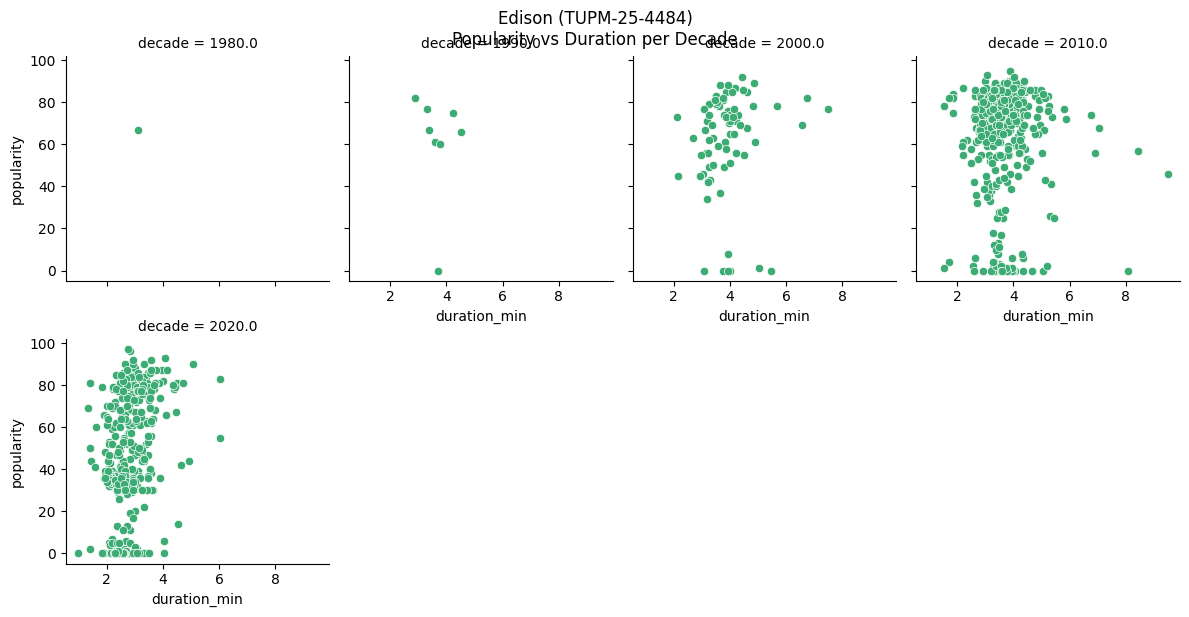

In [39]:
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity',
color=color1)
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02)
plt.show()

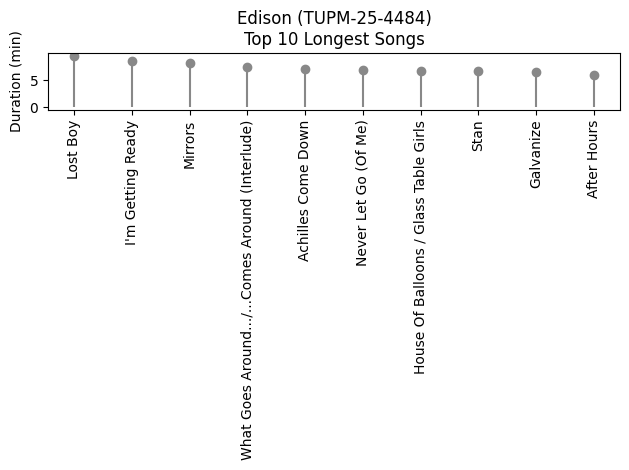

In [40]:
longest = df.nlargest(10, 'duration_min')
plt.stem(longest['track_name'], longest['duration_min'],
linefmt='#888888', markerfmt='o', basefmt=" ")
plt.xticks(rotation=90)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()

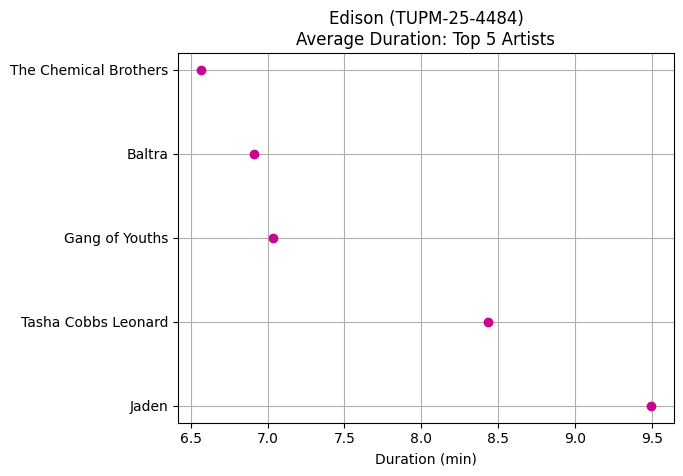

In [42]:
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2)
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists")
plt.xlabel('Duration (min)')
plt.grid(True)
plt.show()

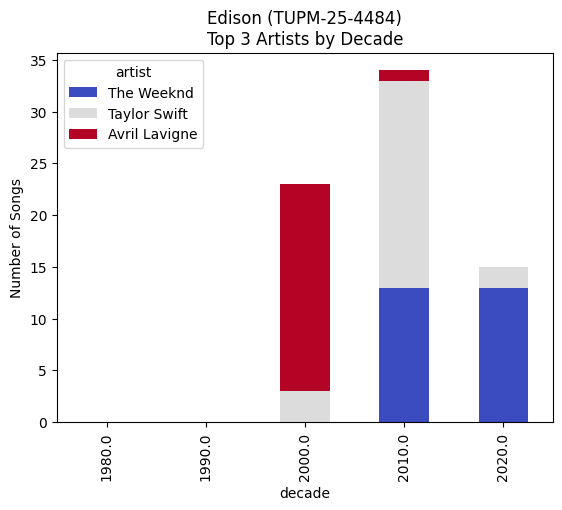

In [43]:
crosstab = pd.crosstab(df['decade'], df['artist'])
top3 = df['artist'].value_counts().head(3).index
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade")
plt.ylabel('Number of Songs')
plt.show()


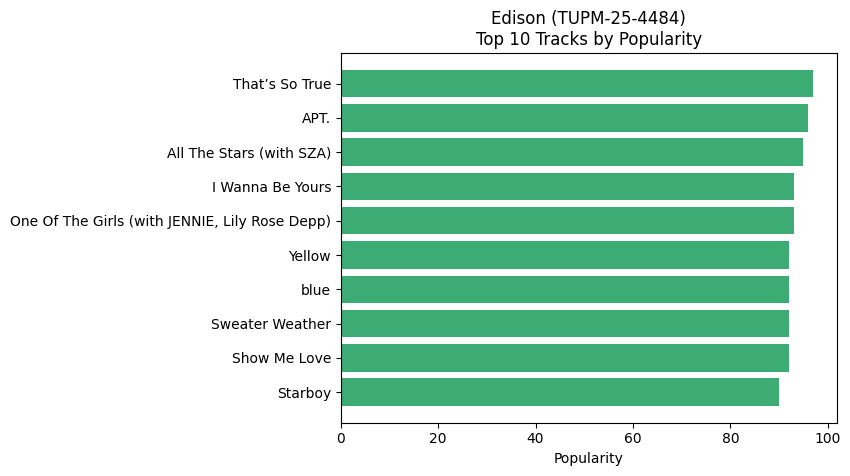

In [44]:
top_tracks = df.nlargest(10, 'popularity')
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1)
plt.xlabel('Popularity')
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity")
plt.gca().invert_yaxis()
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_20148\689365534.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
C:\Users\admin\AppData\Local\Temp\ipykernel_20148\689365534.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',


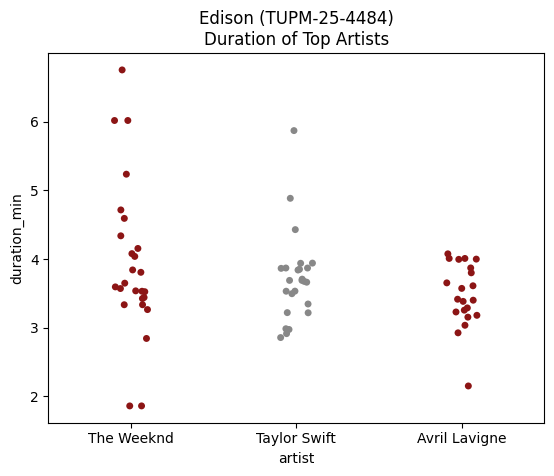

In [45]:
top_artists = df['artist'].value_counts().head(3).index
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
y='duration_min', palette=['#8C1515', '#888888'])
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists")
plt.show()


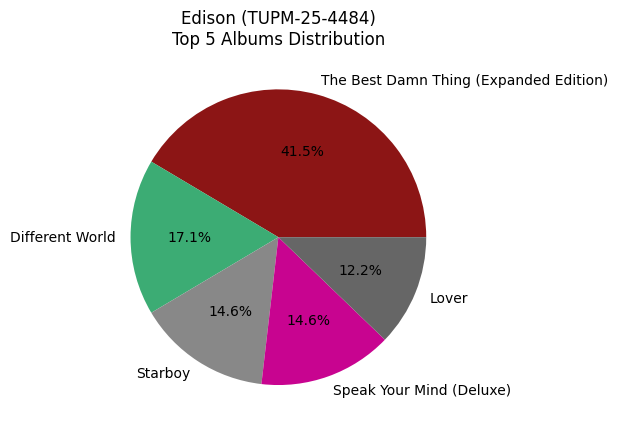

In [46]:
top_albums = df['album'].value_counts().head(5)
colors = ['#8C1515', color1, '#888888', color2, '#666666']
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%',
colors=colors)
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")
plt.show()

In [53]:
numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()
sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis',
linewidths=.75, figsize=(6, 6))
plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features")
plt.show()

RuntimeError: clustermap requires scipy to be available